In [1]:
%pip install --upgrade threadpoolctl scikit-learn matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


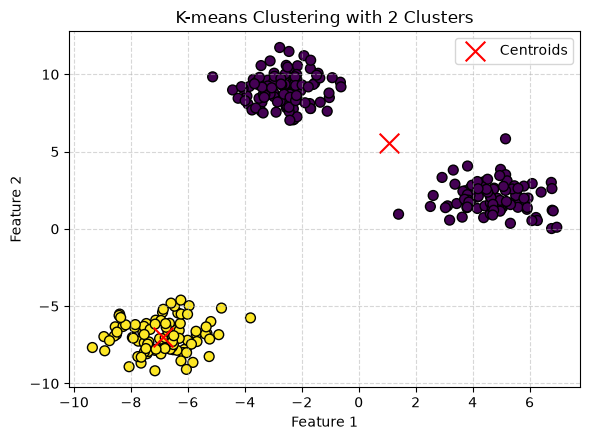

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
 
random_state_value = 42
 
# Generate isotropic Gaussian blobs (300 samples, 3 centers)
np.random.seed(random_state_value)
data, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=random_state_value)
 
# Function to perform K-means clustering and plot the results
def plot_kmeans_clusters(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state_value, n_init='auto')
    labels = kmeans.fit_predict(data)
 
    plt.figure(figsize=(6, 4.5))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='x', s=200, label='Centroids')
    plt.title(f'K-means Clustering with {n_clusters} Clusters')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
 
# Run baseline with K = 2
plot_kmeans_clusters(data, n_clusters=2)


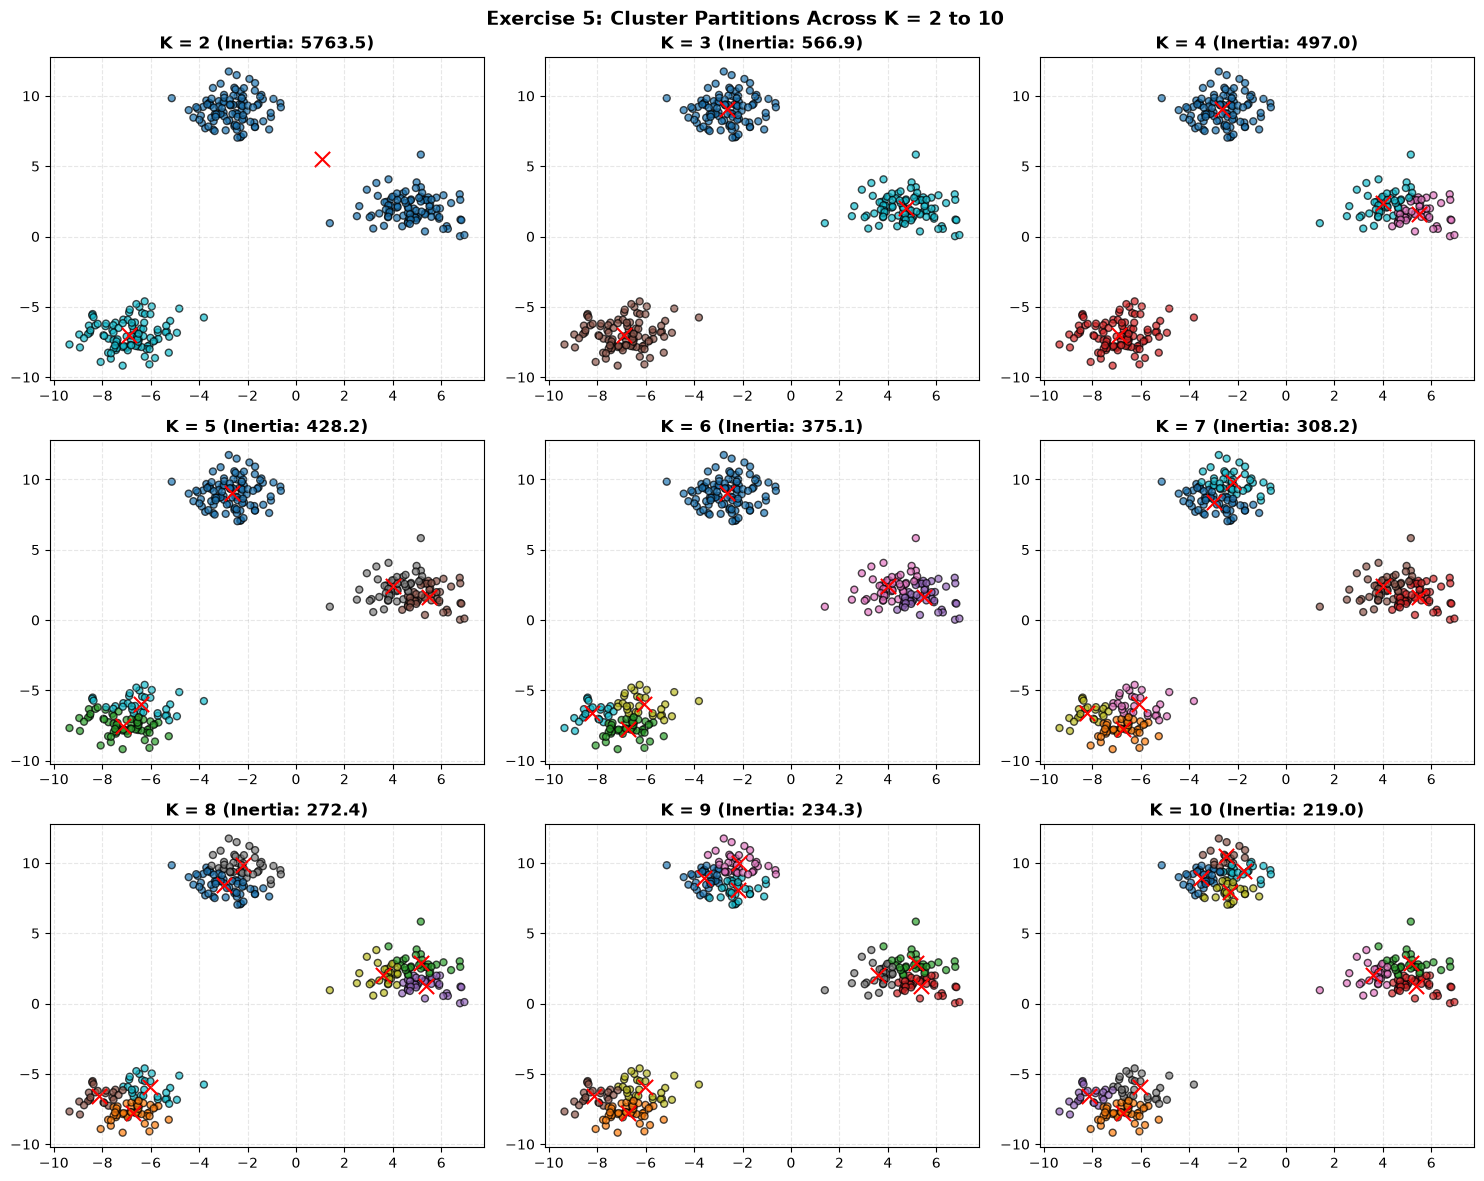

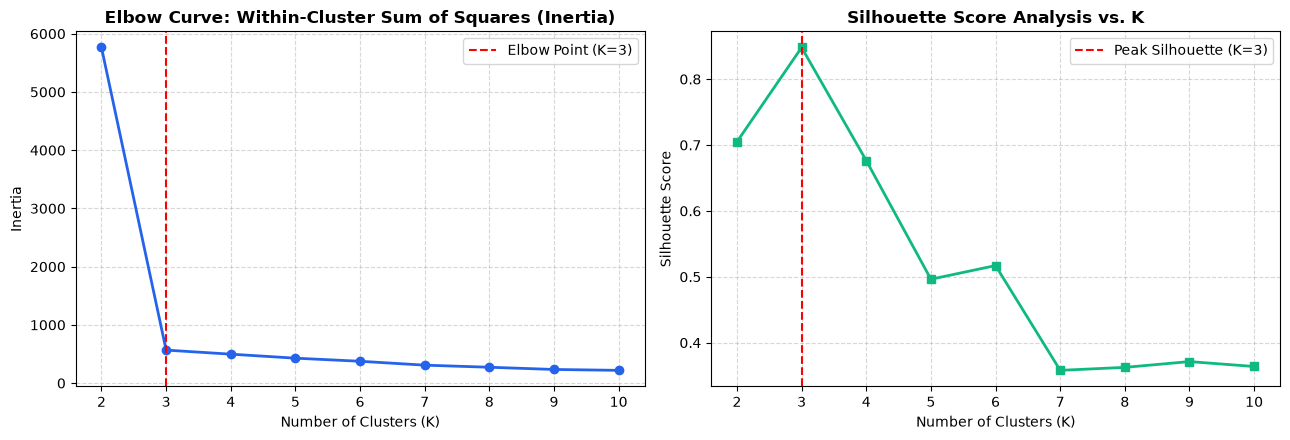

In [3]:
from sklearn.metrics import silhouette_score
 
inertias = []
silhouettes = []
k_values = range(2, 11)
 
# Multi-panel visualization loop
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
 
for idx, k in enumerate(k_values):
    km = KMeans(n_clusters=k, random_state=random_state_value, n_init='auto')
    labels = km.fit_predict(data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(data, labels))
 
    ax = axes[idx]
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=25, edgecolor='k', alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='red', marker='x', s=120)
    ax.set_title(f'K = {k} (Inertia: {km.inertia_:.1f})', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
 
plt.suptitle('Exercise 5: Cluster Partitions Across K = 2 to 10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Diagnostic Elbow and Silhouette Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(k_values, inertias, marker='o', color='#2563EB', linewidth=2)
ax1.axvline(x=3, color='red', linestyle='--', label='Elbow Point (K=3)')
ax1.set_title('Elbow Curve: Within-Cluster Sum of Squares (Inertia)', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
 
ax2.plot(k_values, silhouettes, marker='s', color='#10B981', linewidth=2)
ax2.axvline(x=3, color='red', linestyle='--', label='Peak Silhouette (K=3)')
ax2.set_title('Silhouette Score Analysis vs. K', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
# Testing centroid stability across different random seeds
random_states = [0, 7, 42, 99, 123, 2026]
 
print("=== EXERCISE 6: RANDOM STATE SENSITIVITY TEST (K=3, n_init=1) ===")
for seed in random_states:
    km_test = KMeans(n_clusters=3, random_state=seed, n_init=1)
    km_test.fit(data)
    print(f"Seed: {seed:<5} | Inertia: {km_test.inertia_:.4f} | Converged Iterations: {km_test.n_iter_}")


=== EXERCISE 6: RANDOM STATE SENSITIVITY TEST (K=3, n_init=1) ===
Seed: 0     | Inertia: 566.8596 | Converged Iterations: 2
Seed: 7     | Inertia: 566.8596 | Converged Iterations: 2
Seed: 42    | Inertia: 566.8596 | Converged Iterations: 2
Seed: 99    | Inertia: 566.8596 | Converged Iterations: 2
Seed: 123   | Inertia: 566.8596 | Converged Iterations: 2
Seed: 2026  | Inertia: 566.8596 | Converged Iterations: 2


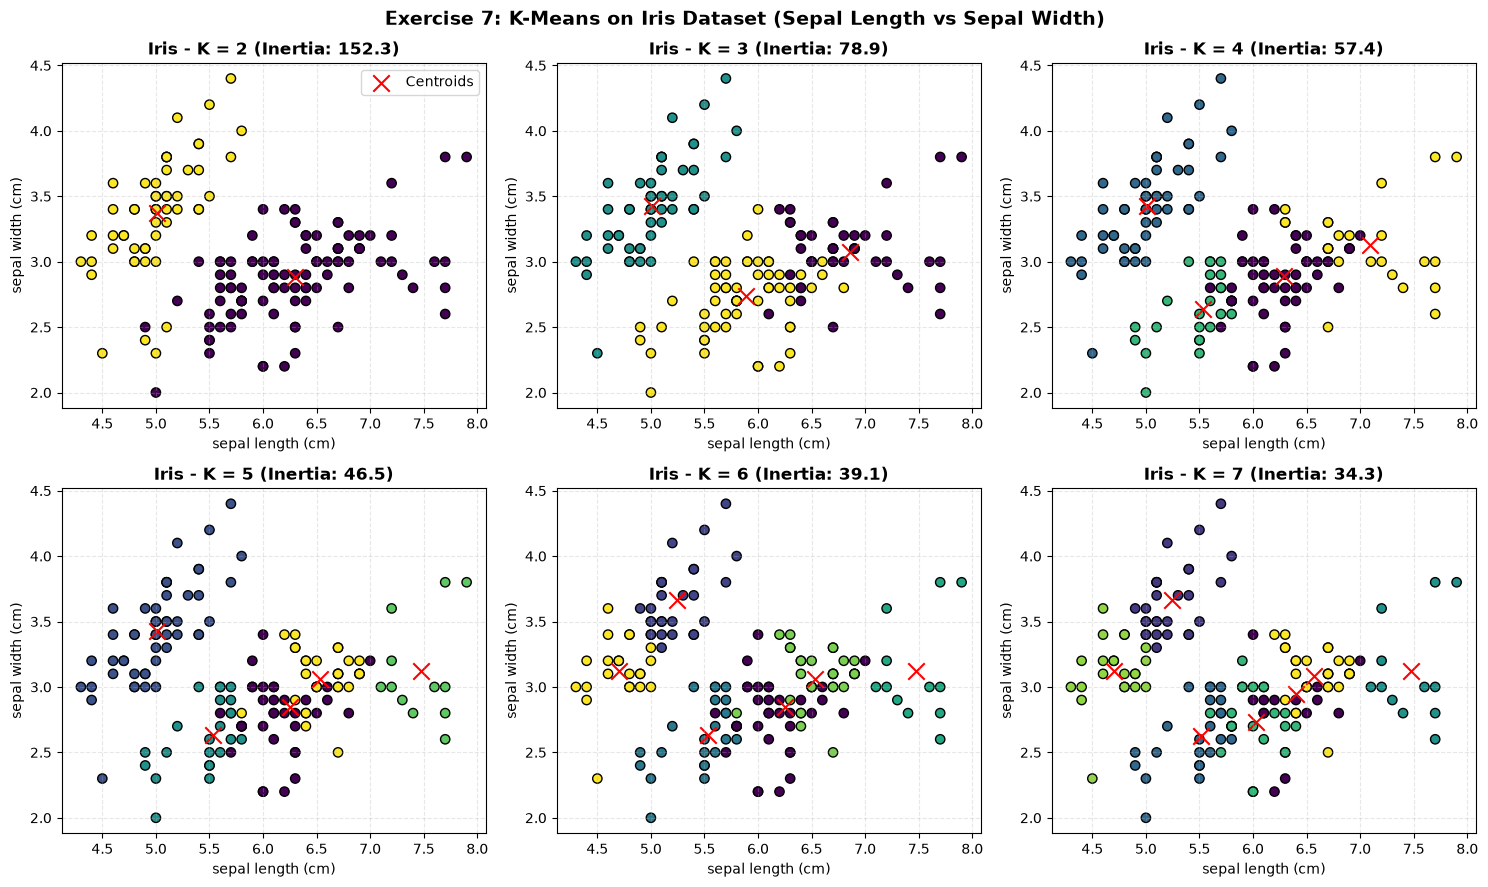

In [5]:
from sklearn.datasets import load_iris
 
# Load the Iris dataset (4 continuous attributes)
iris = load_iris()
iris_data = iris.data
iris_feature_names = iris.feature_names
 
# Plot the data across specified cluster numbers
N = [2, 3, 4, 5, 6, 7]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
for idx, n in enumerate(N):
    km_iris = KMeans(n_clusters=n, random_state=random_state_value, n_init='auto')
    labels_iris = km_iris.fit_predict(iris_data)
 
    ax = axes[idx]
    ax.scatter(iris_data[:, 0], iris_data[:, 1], c=labels_iris, cmap='viridis', edgecolor='k', s=45)
    ax.scatter(km_iris.cluster_centers_[:, 0], km_iris.cluster_centers_[:, 1],
               c='red', marker='x', s=140, label='Centroids')
    ax.set_title(f'Iris - K = {n} (Inertia: {km_iris.inertia_:.1f})', fontweight='bold')
    ax.set_xlabel(iris_feature_names[0])
    ax.set_ylabel(iris_feature_names[1])
    ax.grid(True, linestyle='--', alpha=0.3)
    if idx == 0:
        ax.legend()
 
plt.suptitle('Exercise 7: K-Means on Iris Dataset (Sepal Length vs Sepal Width)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


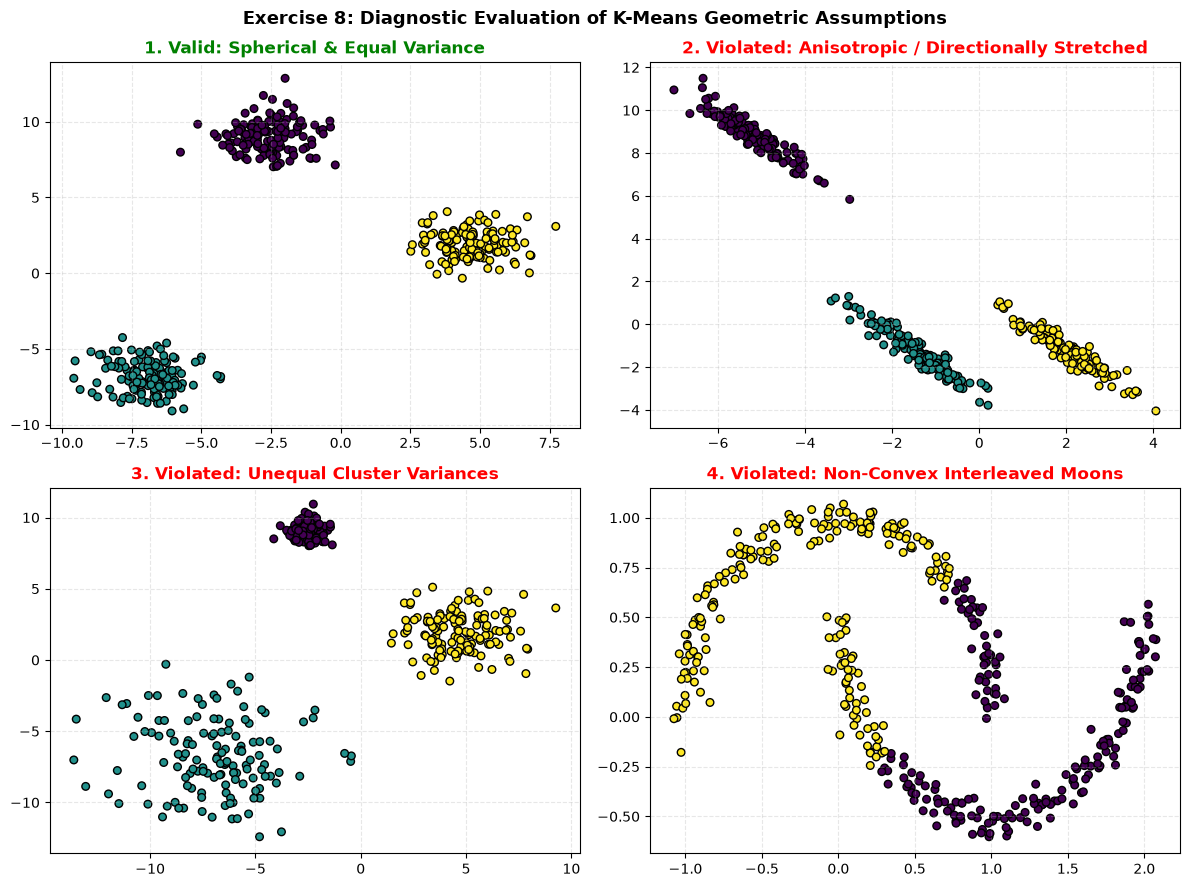

In [6]:
from sklearn.datasets import make_moons
 
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))
 
# 1. Valid Assumption: Spherical isotropic blobs
X1, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=42)
pred1 = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(X1)
ax1.scatter(X1[:, 0], X1[:, 1], c=pred1, cmap='viridis', edgecolor='k', s=30)
ax1.set_title('1. Valid: Spherical & Equal Variance', fontweight='bold', color='green')
 
# 2. Violated Assumption: Anisotropic (stretched) distributions
X2, _ = make_blobs(n_samples=400, centers=3, random_state=42)
X2 = np.dot(X2, [[0.6, -0.6], [-0.4, 0.8]])
pred2 = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(X2)
ax2.scatter(X2[:, 0], X2[:, 1], c=pred2, cmap='viridis', edgecolor='k', s=30)
ax2.set_title('2. Violated: Anisotropic / Directionally Stretched', fontweight='bold', color='red')
 
# 3. Violated Assumption: Unequal variances
X3, _ = make_blobs(n_samples=400, centers=3, cluster_std=[0.5, 1.5, 2.5], random_state=42)
pred3 = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(X3)
ax3.scatter(X3[:, 0], X3[:, 1], c=pred3, cmap='viridis', edgecolor='k', s=30)
ax3.set_title('3. Violated: Unequal Cluster Variances', fontweight='bold', color='red')
 
# 4. Violated Assumption: Non-convex manifold shapes (Moons)
X4, _ = make_moons(n_samples=400, noise=0.05, random_state=42)
pred4 = KMeans(n_clusters=2, random_state=42, n_init='auto').fit_predict(X4)
ax4.scatter(X4[:, 0], X4[:, 1], c=pred4, cmap='viridis', edgecolor='k', s=30)
ax4.set_title('4. Violated: Non-Convex Interleaved Moons', fontweight='bold', color='red')
 
for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True, linestyle='--', alpha=0.3)
 
plt.suptitle('Exercise 8: Diagnostic Evaluation of K-Means Geometric Assumptions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


=== EXERCISE 9: CUSTOMER RFM PROFILES ===


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,18.15,4.69,593.39,254
1,21.83,8.26,1162.64,163
2,83.11,5.60,711.45,83


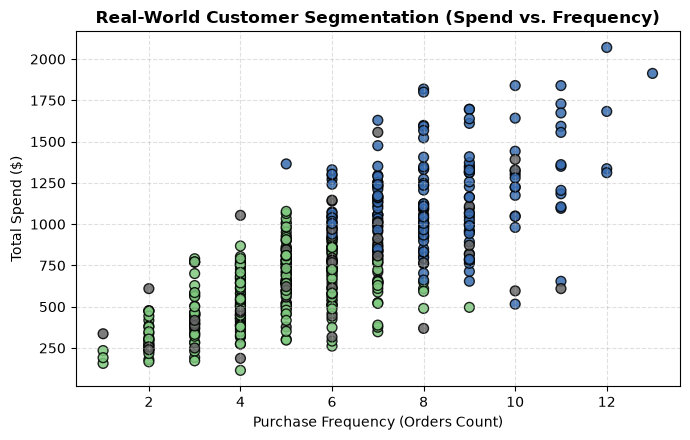

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
 
# Generate simulated Online Retail RFM dataset (500 customers)
np.random.seed(42)
n_cust = 500
 
recency = np.random.exponential(scale=30, size=n_cust)
frequency = np.random.poisson(lam=5, size=n_cust) + 1
monetary = frequency * np.random.normal(loc=120, scale=35, size=n_cust) + np.random.exponential(scale=100, size=n_cust)
 
rfm = pd.DataFrame({'Recency': recency, 'Frequency': frequency, 'Monetary': monetary})
 
# Scale features to remove dimensional magnitude bias
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
 
# Train K-Means (K=3)
kmeans_rfm = KMeans(n_clusters=3, random_state=42, n_init='auto')
rfm['Cluster'] = kmeans_rfm.fit_predict(rfm_scaled)
 
print("=== EXERCISE 9: CUSTOMER RFM PROFILES ===")
profile = rfm.groupby('Cluster').mean().round(2)
profile['Customer_Count'] = rfm['Cluster'].value_counts()
display(profile)
 
# Scatter plot of customer segments
plt.figure(figsize=(7, 4.5))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='Accent', edgecolor='k', s=50, alpha=0.85)
plt.title('Real-World Customer Segmentation (Spend vs. Frequency)', fontweight='bold')
plt.xlabel('Purchase Frequency (Orders Count)')
plt.ylabel('Total Spend ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
